# Exploratory Data Analysis

Before we model anything we want to know:

1. How big is the dataset, and is it complete (no missing, no duplicates)?
2. What does the target variable Yield look like, and how does it differ across crop / season / soil type?
3. Do any of the raw input columns have a usable correlation with Yield?

If the answer to question 3 is poor, we will need engineered features in notebook 02.

## Imports

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
RAW_PATH = ROOT / 'data' / 'raw' / 'Agri_yield_prediction.csv'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load the raw CSV

In [2]:
df = pd.read_csv(RAW_PATH)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.head()

Rows: 36000
Columns: 46


,Temperature,Humidity,Rainfall,Soil_Type,pH,EC,OC,N,P,K,...,Planting_Date,Harvest_Date,Growth_Stage,Irrigation_Frequency,Fertilizer_Type,Pesticide_Usage,Yield,Region,Season,Year
0,20.217609,71.563782,48.837768,Clayey,6.467371,1.317873,0.656934,138.565862,65.148562,197.716636,...,2023-10-19,2024-01-29,Vegetative,4,Organic,Low,5.340428,West,Rabi,2023
1,34.144330,62.473178,253.900950,Sandy,7.087405,1.564200,0.748017,82.633876,37.236441,99.902932,...,2009-08-23,2009-11-13,Reproductive,4,Mixed,High,6.633464,North,Kharif,2009
2,20.842568,60.215798,128.300095,Loamy,6.685763,1.162799,1.185390,140.045407,72.826335,151.476596,...,2022-12-23,2023-04-11,Vegetative,5,Mixed,High,7.088017,South,Rabi,2022
3,26.367346,60.933355,159.439204,Sandy,7.200194,0.881416,0.794367,109.949204,49.583849,200.372264,...,2023-08-10,2023-11-09,Vegetative,9,Chemical,High,5.798286,North,Kharif,2023
4,24.748865,71.095366,170.084596,Sandy,6.670267,1.547674,1.081402,99.444634,64.207218,174.627078,...,2003-08-05,2003-10-22,Maturity,4,Organic,High,9.923957,South,Kharif,2003


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature             36000 non-null  float64
 1   Humidity                36000 non-null  float64
 2   Rainfall                36000 non-null  float64
 3   Soil_Type               36000 non-null  object 
 4   pH                      36000 non-null  float64
 5   EC                      36000 non-null  float64
 6   OC                      36000 non-null  float64
 7   N                       36000 non-null  float64
 8   P                       36000 non-null  float64
 9   K                       36000 non-null  float64
 10  Ca                      36000 non-null  float64
 11  Mg                      36000 non-null  float64
 12  S                       36000 non-null  float64
 13  Zn                      36000 non-null  float64
 14  Fe                      36000 non-null

## Data quality

In [4]:
missing = df.isna().sum()
print('Total missing values:', int(missing.sum()))
missing[missing > 0]

Total missing values: 0


Series([], dtype: int64)

In [5]:
duplicates = int(df.duplicated().sum())
print('Duplicate rows:', duplicates)

Duplicate rows: 0


Zero missing values and zero duplicates. No imputation or deduplication needed.

## Yield distribution

In [6]:
df['Yield'].describe().round(3)

count    36000.000
mean         6.430
std          2.296
min          1.000
25%          4.753
50%          6.324
75%          8.235
max         10.000
Name: Yield, dtype: float64

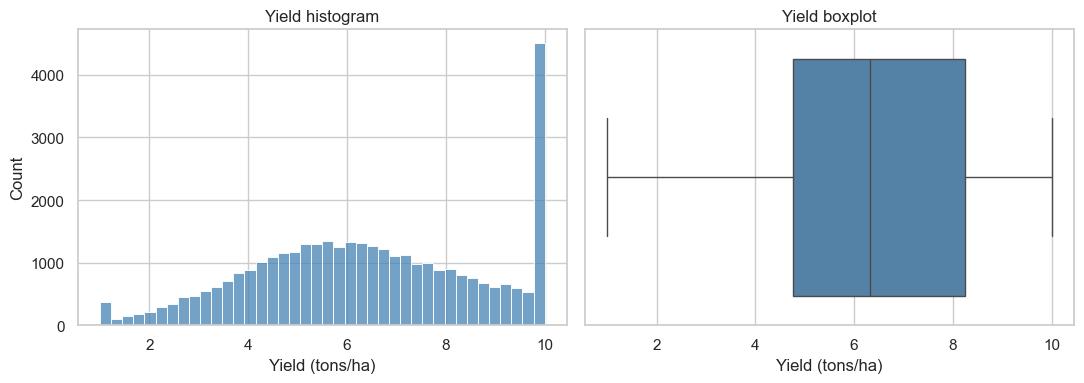

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Yield'], bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Yield histogram')
axes[0].set_xlabel('Yield (tons/ha)')
sns.boxplot(x=df['Yield'], color='steelblue', ax=axes[1])
axes[1].set_title('Yield boxplot')
axes[1].set_xlabel('Yield (tons/ha)')
fig.tight_layout()
fig.savefig(FIG_DIR / '01_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Yield is roughly bell-shaped, ranges 1 to 10 tons/ha, mean around 6.4. The boxplot shows no extreme outliers.